# Notebook 3: Response Data — The Binary Response Matrix

This notebook explores **`data_responses.csv`** (wide format, 881 × 18) and **`data_long.csv`** (long format, 15858 rows).

Each cell is **0** (incorrect) or **1** (correct). This is the core data that IRT models analyze.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', message='vert.*deprecated.*orientation')
warnings.filterwarnings('ignore', message='set_ticklabels.*should only be used')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

## 1. Raw Response Matrix: `data_responses.csv`

Each row = one student, each column = one item.  Values are 0 or 1.

In [2]:
resp = pd.read_csv('data_responses.csv')
print(f'Shape: {resp.shape[0]} rows × {resp.shape[1]} columns')
print(f'Columns: {list(resp.columns)}')
print()
resp.head(15)

Shape: 881 rows × 19 columns
Columns: ['person_id', 'Ari_Tech_1', 'Ari_Tech_2', 'Ari_Nume_1', 'Ari_Nume_2', 'Ari_Abst_1', 'Ari_Abst_2', 'Geo_Tech_1', 'Geo_Tech_2', 'Geo_Nume_1', 'Geo_Nume_2', 'Geo_Abst_1', 'Geo_Abst_2', 'Alg_Tech_1', 'Alg_Tech_2', 'Alg_Nume_1', 'Alg_Nume_2', 'Alg_Abst_1', 'Alg_Abst_2']



,person_id,Ari_Tech_1,Ari_Tech_2,Ari_Nume_1,Ari_Nume_2,Ari_Abst_1,Ari_Abst_2,Geo_Tech_1,Geo_Tech_2,Geo_Nume_1,Geo_Nume_2,Geo_Abst_1,Geo_Abst_2,Alg_Tech_1,Alg_Tech_2,Alg_Nume_1,Alg_Nume_2,Alg_Abst_1,Alg_Abst_2
0,0,1,1,0,0,1,1,1,0,1,1,1,1,1,1,1,1,1,1
1,1,1,0,0,1,1,1,0,0,0,1,1,0,0,1,0,0,0,0
2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0
3,3,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,0,1
4,4,1,1,0,1,0,0,1,1,0,1,0,1,1,0,0,0,1,0
5,5,1,1,0,0,1,1,0,1,0,1,0,0,1,1,1,0,0,1
6,6,1,1,1,0,1,1,1,1,1,1,0,1,1,1,1,0,0,1
7,7,0,1,0,0,1,1,0,1,0,1,1,0,1,1,0,0,0,0
8,8,1,0,1,1,1,1,0,1,1,1,0,1,0,1,1,1,1,0
9,9,0,1,1,0,0,0,1,1,0,1,1,1,0,0,0,0,0,1


In [3]:
# The last few students
resp.tail(10)

,person_id,Ari_Tech_1,Ari_Tech_2,Ari_Nume_1,Ari_Nume_2,Ari_Abst_1,Ari_Abst_2,Geo_Tech_1,Geo_Tech_2,Geo_Nume_1,Geo_Nume_2,Geo_Abst_1,Geo_Abst_2,Alg_Tech_1,Alg_Tech_2,Alg_Nume_1,Alg_Nume_2,Alg_Abst_1,Alg_Abst_2
871,871,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
872,872,1,0,0,1,0,0,1,0,0,0,0,0,1,1,1,0,0,0
873,873,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1
874,874,1,1,1,0,0,1,0,1,0,0,1,0,1,1,0,0,0,0
875,875,1,1,1,1,1,1,0,1,1,1,1,1,0,1,0,0,0,0
876,876,0,1,1,0,0,1,1,0,0,1,0,0,0,1,1,0,0,1
877,877,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0
878,878,1,1,0,1,1,1,1,1,1,0,0,1,0,1,0,1,1,0
879,879,1,1,0,1,1,1,1,0,0,1,1,1,0,0,1,0,0,1
880,880,0,1,1,1,1,1,0,1,0,1,1,0,1,1,1,1,1,0


In [4]:
# Extract numeric matrix (drop person_id)
R = resp.drop(columns=['person_id']).values
item_names = resp.columns[1:].tolist()
N, I = R.shape
print(f'Response matrix: {N} persons × {I} items')
print(f'Total responses: {N * I}')
print(f'Ones (correct):  {R.sum()} ({R.mean()*100:.1f}%)')
print(f'Zeros (wrong):   {(1-R).sum().astype(int)} ({(1-R.mean())*100:.1f}%)')

Response matrix: 881 persons × 18 items
Total responses: 15858
Ones (correct):  9948 (62.7%)
Zeros (wrong):   5910 (37.3%)


## Guttman Structure: The Ideal Scalogram

In a **perfect Guttman scale**, if we sort persons by total score (high→low) and items by facility (easy→hard), all "1"s concentrate in the **upper-left triangle** and all "0"s in the **lower-right triangle**, forming a staircase boundary.

Real data never shows a perfect pattern, but the Rasch model assumes responses approximate this structure. The degree to which the data deviates from the Guttman pattern reflects misfit and noise.

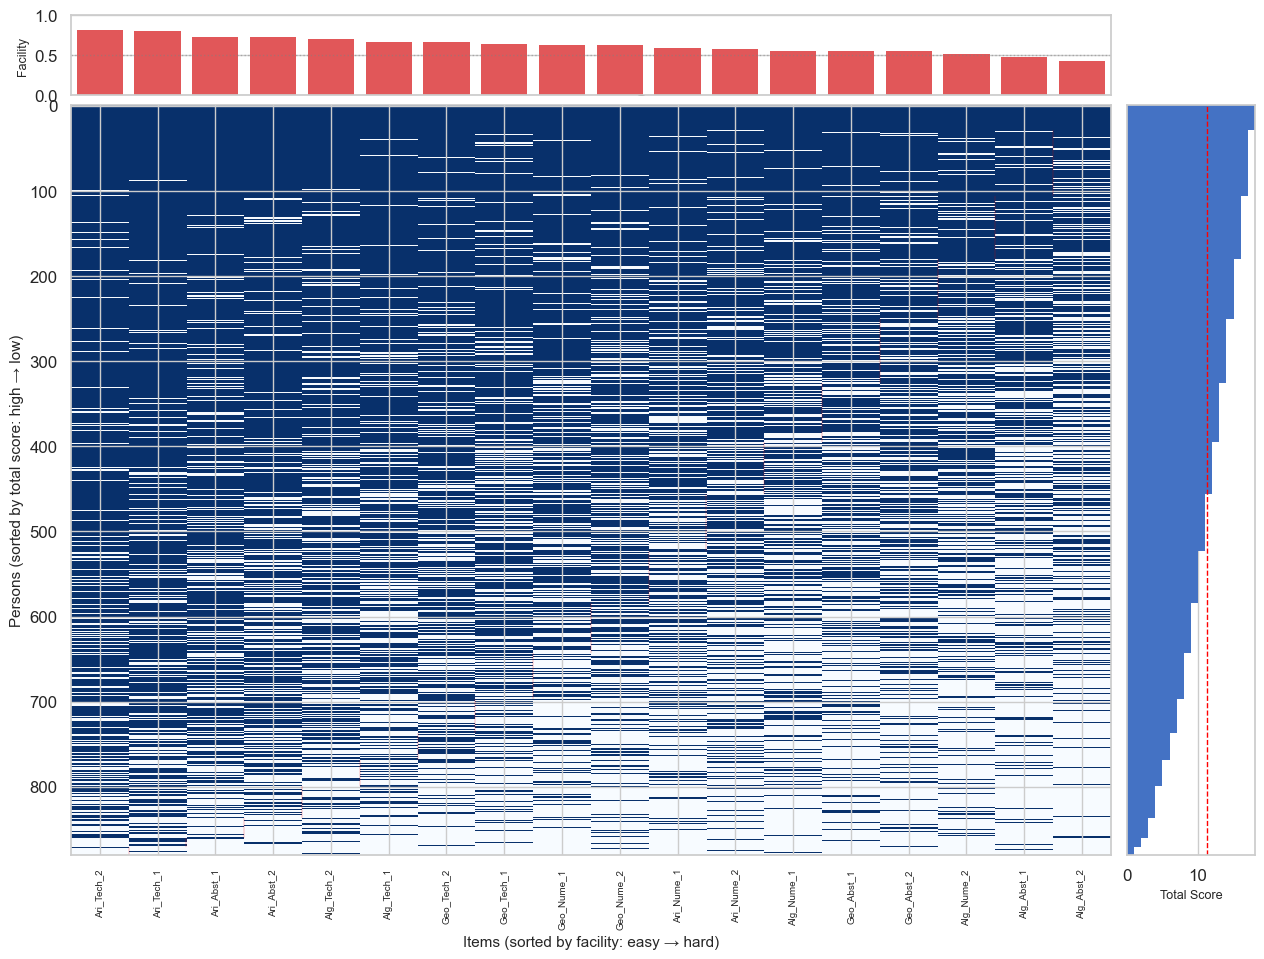

Guttman scalogram diagnostics:
  Total cells:                15,858
  Cells deviating from ideal: 4,360 (27.5%)
  Coefficient of Reproducibility (Rep): 0.725
  (Rep ≥ 0.90 is traditionally considered acceptable)

The staircase pattern is visible — high-scoring persons (top)
answer easy items (left) correctly, and low-scoring persons (bottom)
fail hard items (right). Deviations reflect measurement noise,
which the Rasch model accounts for probabilistically.


In [5]:
# ── Guttman Scalogram: sort persons by total score, items by facility ──

# Person total scores and item facilities (proportion correct)
person_totals = R.sum(axis=1)          # shape (881,)
item_facility = R.mean(axis=0)         # shape (18,)

# Sort: persons descending by total score, items descending by facility (easy first)
person_order = np.argsort(person_totals)[::-1]   # high scorers on top
item_order = np.argsort(item_facility)[::-1]      # easy items on the left

R_guttman = R[person_order][:, item_order]
sorted_item_names = [item_names[i] for i in item_order]
sorted_facility = item_facility[item_order]
sorted_totals = person_totals[person_order]

# ── Figure: Guttman heatmap with marginals ──
fig = plt.figure(figsize=(16, 10))

# Main heatmap
ax_main = fig.add_axes([0.12, 0.12, 0.65, 0.75])
ax_main.imshow(R_guttman, aspect='auto', cmap='Blues', interpolation='nearest')
ax_main.set_xticks(range(I))
ax_main.set_xticklabels(sorted_item_names, rotation=90, fontsize=7)
ax_main.set_ylabel('Persons (sorted by total score: high \u2192 low)', fontsize=11)
ax_main.set_xlabel('Items (sorted by facility: easy \u2192 hard)', fontsize=11)
ax_main.set_title('Guttman Scalogram', fontweight='bold', fontsize=14, pad=10)

# Draw the theoretical Guttman boundary (staircase)
# For each person with total score s, the boundary falls after item s
for p_idx in range(N):
    s = int(sorted_totals[p_idx])
    if s > 0 and s < I:
        ax_main.plot([s - 0.5, s - 0.5], [p_idx - 0.5, p_idx + 0.5],
                     color='red', linewidth=0.3, alpha=0.5)

# Right margin: person total scores
ax_right = fig.add_axes([0.78, 0.12, 0.08, 0.75])
ax_right.barh(range(N), sorted_totals, color='#4472C4', edgecolor='none', height=1.0)
ax_right.set_ylim(N - 0.5, -0.5)
ax_right.set_xlabel('Total Score', fontsize=9)
ax_right.set_yticks([])
ax_right.set_xlim(0, I)
ax_right.axvline(sorted_totals.mean(), color='red', linestyle='--', lw=1)

# Top margin: item facility (p-values)
ax_top = fig.add_axes([0.12, 0.88, 0.65, 0.08])
ax_top.bar(range(I), sorted_facility, color='#E15759', edgecolor='none', width=0.8)
ax_top.set_xlim(-0.5, I - 0.5)
ax_top.set_ylim(0, 1)
ax_top.set_xticks([])
ax_top.set_ylabel('Facility', fontsize=9)
ax_top.axhline(0.5, color='gray', linestyle=':', lw=1, alpha=0.5)

plt.show()

# ── Summary statistics about the Guttman pattern ──
# Count errors: 0s above the diagonal (should be 1) and 1s below (should be 0)
n_errors = 0
for p_idx in range(N):
    s = int(sorted_totals[p_idx])
    # Expected pattern: first s items = 1, remaining = 0
    expected = np.zeros(I)
    expected[:s] = 1
    n_errors += int(np.sum(R_guttman[p_idx] != expected))

total_cells = N * I
error_rate = n_errors / total_cells * 100
coeff_repro = 1 - n_errors / total_cells

print(f'Guttman scalogram diagnostics:')
print(f'  Total cells:                {total_cells:,}')
print(f'  Cells deviating from ideal: {n_errors:,} ({error_rate:.1f}%)')
print(f'  Coefficient of Reproducibility (Rep): {coeff_repro:.3f}')
print(f'  (Rep \u2265 0.90 is traditionally considered acceptable)')
print()
print(f'The staircase pattern is visible \u2014 high-scoring persons (top)')
print(f'answer easy items (left) correctly, and low-scoring persons (bottom)')
print(f'fail hard items (right). Deviations reflect measurement noise,')
print(f'which the Rasch model accounts for probabilistically.')

## 2. Visualizing the Full Response Matrix

A heatmap of all 881 × 18 responses — black = correct (1), white = incorrect (0).

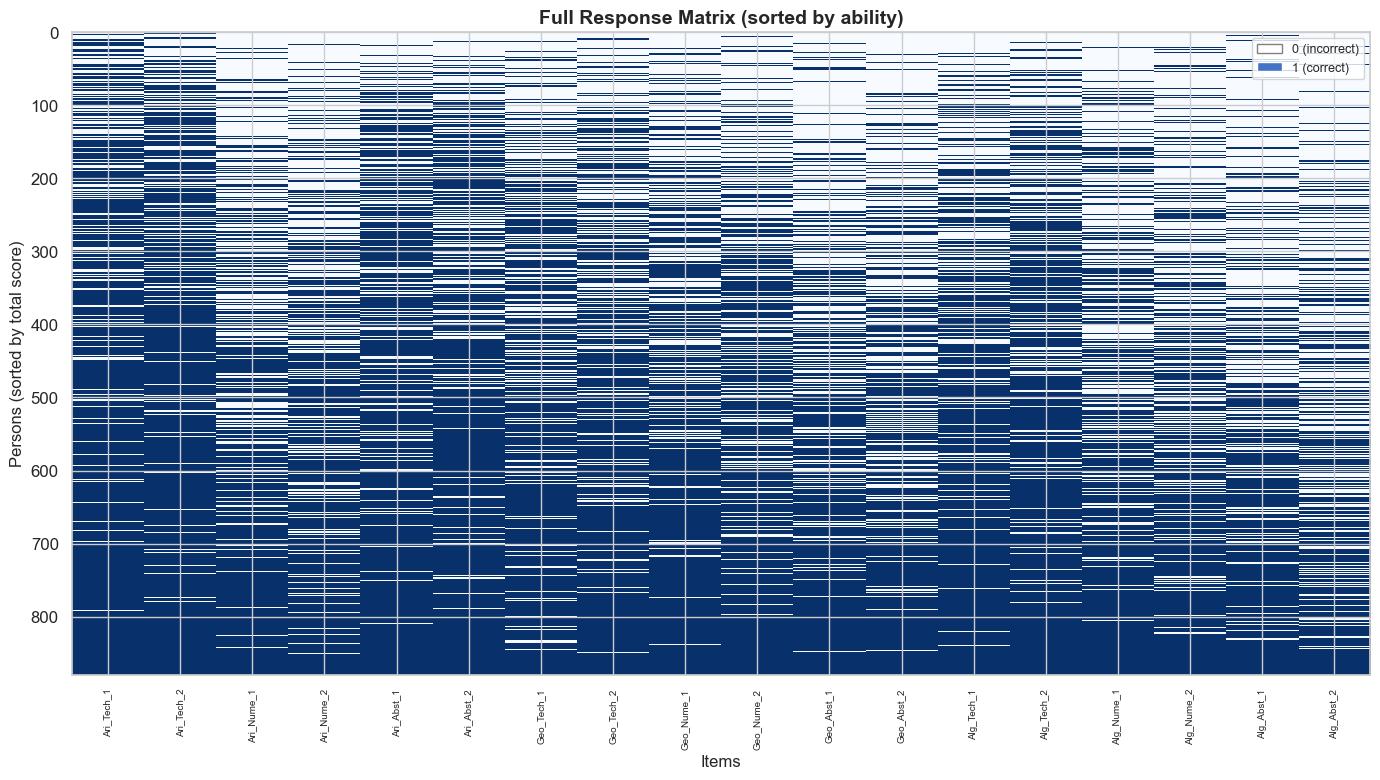

In [6]:
# Sort persons by sum score for visual clarity
sum_scores = R.sum(axis=1)
sort_idx = np.argsort(sum_scores)
R_sorted = R[sort_idx]

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(R_sorted, aspect='auto', cmap='Blues', interpolation='nearest')
ax.set_xlabel('Items', fontsize=12)
ax.set_ylabel('Persons (sorted by total score)', fontsize=12)
ax.set_xticks(range(I))
ax.set_xticklabels(item_names, rotation=90, fontsize=7)
ax.set_title('Full Response Matrix (sorted by ability)', fontweight='bold', fontsize=14)

# Add a colorbar legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='white', edgecolor='gray', label='0 (incorrect)'),
                   Patch(facecolor='#4472C4', label='1 (correct)')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

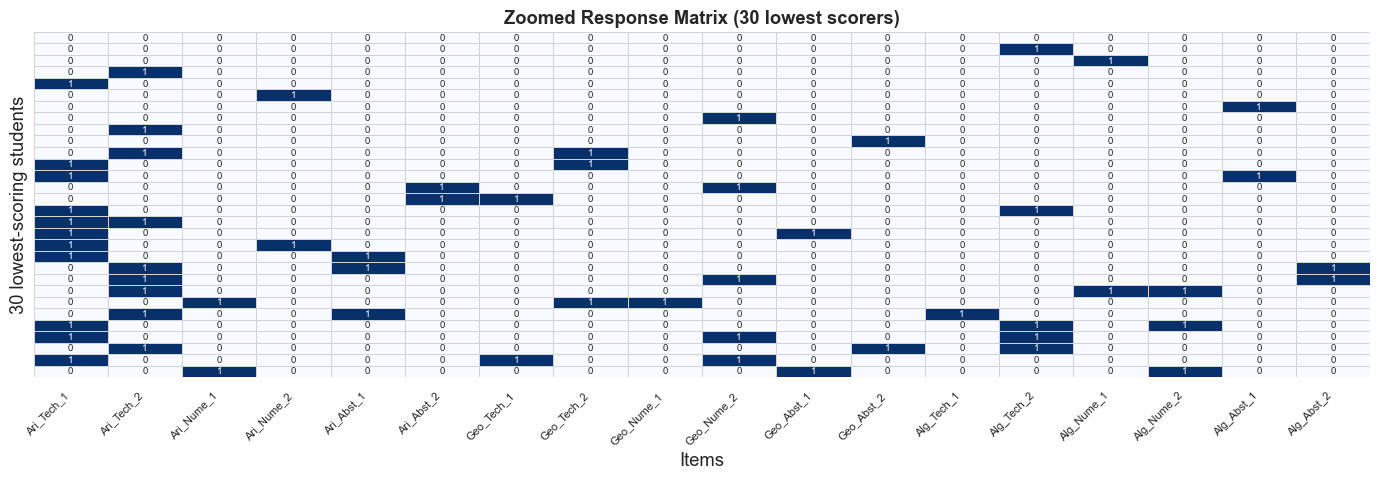

In [7]:
# Zoomed-in view: first 30 persons × all items
fig, ax = plt.subplots(figsize=(14, 5))
sub = R_sorted[:30]
sns.heatmap(sub, cmap='Blues', cbar=False, linewidths=0.5, linecolor='lightgray',
            xticklabels=item_names, yticklabels=False, ax=ax,
            annot=True, fmt='d', annot_kws={'fontsize': 7})
ax.set_xlabel('Items'); ax.set_ylabel('30 lowest-scoring students')
ax.set_title('Zoomed Response Matrix (30 lowest scorers)', fontweight='bold')
ax.set_xticklabels(item_names, rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Item-Level Statistics (p-values)

The **item p-value** = proportion of students answering correctly.  Easy items have high p-values.

In [8]:
items = pd.read_csv('data_items.csv')
item_pvals = R.mean(axis=0)
items['p_value'] = item_pvals

print('Item p-values (proportion correct):')
items[['item_name', 'topic_area', 'modeling_type', 'p_value', 'beta_true']].sort_values('p_value', ascending=False)

Item p-values (proportion correct):


,item_name,topic_area,modeling_type,p_value,beta_true
1,Ari_Tech_2,Arithmetic,TechnicalProcessing,0.817253,-1.171061
0,Ari_Tech_1,Arithmetic,TechnicalProcessing,0.805902,-1.120263
4,Ari_Abst_1,Arithmetic,AbstractModeling,0.735528,-0.528732
5,Ari_Abst_2,Arithmetic,AbstractModeling,0.725312,-0.528731
13,Alg_Tech_2,Algebra,TechnicalProcessing,0.699205,-0.283062
12,Alg_Tech_1,Algebra,TechnicalProcessing,0.666288,-0.110643
7,Geo_Tech_2,Geometry,TechnicalProcessing,0.664018,-0.138605
6,Geo_Tech_1,Geometry,TechnicalProcessing,0.641317,-0.073663
8,Geo_Nume_1,Geometry,NumericalModeling,0.633371,0.032442
9,Geo_Nume_2,Geometry,NumericalModeling,0.628831,0.113405


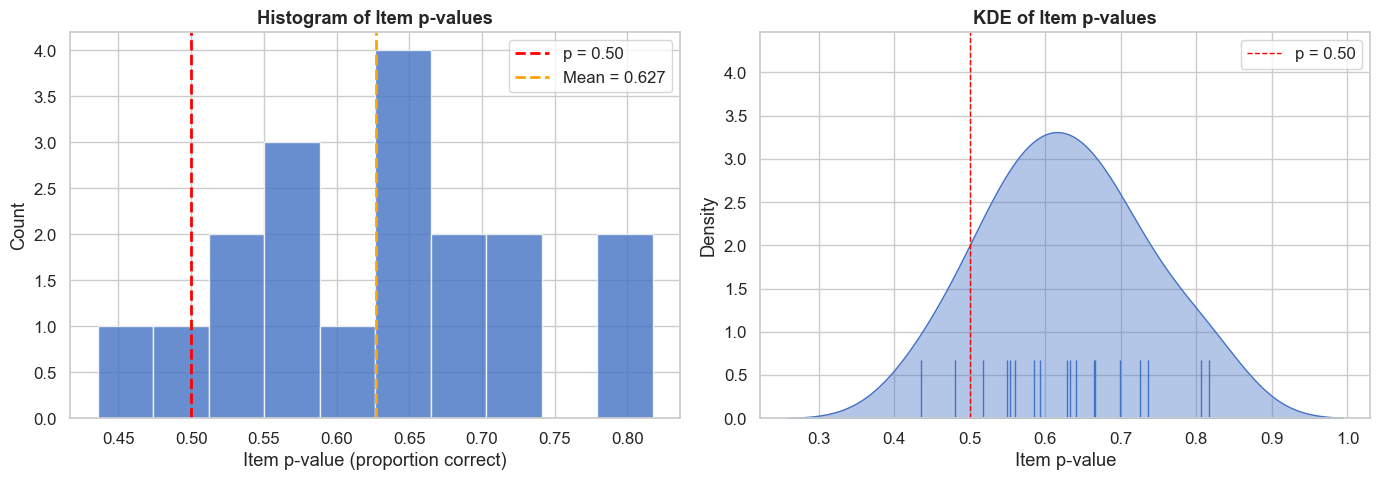

In [9]:
# ── Histogram and KDE of item p-values ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(item_pvals, bins=10, color='#4472C4', edgecolor='white', alpha=0.8)
ax.axvline(0.5, color='red', linestyle='--', lw=2, label='p = 0.50')
ax.axvline(item_pvals.mean(), color='orange', linestyle='--', lw=2, label=f'Mean = {item_pvals.mean():.3f}')
ax.set_xlabel('Item p-value (proportion correct)'); ax.set_ylabel('Count')
ax.set_title('Histogram of Item p-values', fontweight='bold')
ax.legend()

ax = axes[1]
sns.kdeplot(x=item_pvals, fill=True, color='#4472C4', alpha=0.4, ax=ax)
sns.rugplot(x=item_pvals, color='#4472C4', ax=ax, height=0.15)
ax.axvline(0.5, color='red', linestyle='--', lw=1, label='p = 0.50')
ax.set_xlabel('Item p-value'); ax.set_title('KDE of Item p-values', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

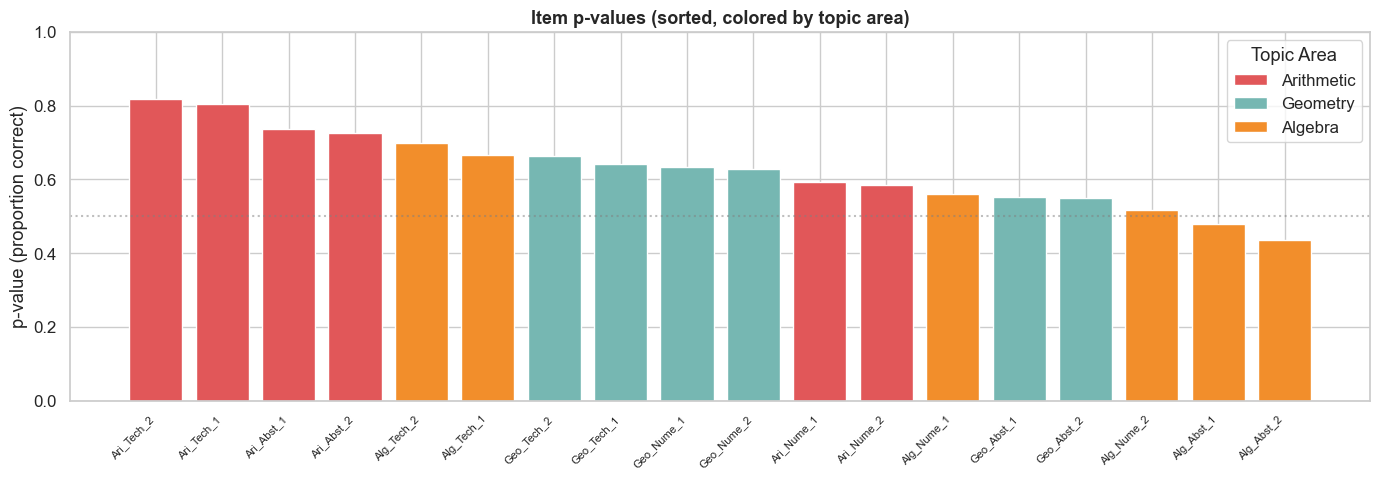

In [10]:
# ── Bar chart: item p-values sorted ──
fig, ax = plt.subplots(figsize=(14, 5))

sorted_idx = np.argsort(item_pvals)[::-1]
sorted_names = [item_names[i] for i in sorted_idx]
sorted_pvals = item_pvals[sorted_idx]
sorted_topics = items['topic_area'].iloc[sorted_idx].values
palette_ta = {'Arithmetic': '#E15759', 'Geometry': '#76B7B2', 'Algebra': '#F28E2B'}
bar_colors = [palette_ta[t] for t in sorted_topics]

bars = ax.bar(range(I), sorted_pvals, color=bar_colors, edgecolor='white')
ax.set_xticks(range(I))
ax.set_xticklabels(sorted_names, rotation=45, ha='right', fontsize=8)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.set_ylabel('p-value (proportion correct)')
ax.set_title('Item p-values (sorted, colored by topic area)', fontweight='bold', fontsize=13)
ax.set_ylim(0, 1)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in palette_ta.items()]
ax.legend(handles=legend_elements, title='Topic Area')

plt.tight_layout()
plt.show()

## 4. Person-Level Statistics (Sum Scores)

In [11]:
persons = pd.read_csv('data_persons.csv')
persons['sum_score'] = R.sum(axis=1)
persons['Program'] = persons['program'].map({1:'1-Hauptschule', 2:'2-Integrated',
                                              3:'3-Realschule', 4:'4-Gymnasium'})
persons['Gender'] = persons['gender'].map({0:'Female', 1:'Male'})

print(f'Sum score range: {persons["sum_score"].min()} – {persons["sum_score"].max()} (out of {I})')
print(f'Mean: {persons["sum_score"].mean():.2f}, SD: {persons["sum_score"].std():.2f}')
print(f'Median: {persons["sum_score"].median()}')
print()
persons[['person_id','Gender','Program','hises','theta_true','sum_score']].head(15)

Sum score range: 0 – 18 (out of 18)
Mean: 11.29, SD: 4.35
Median: 12.0



,person_id,Gender,Program,hises,theta_true,sum_score
0,0,Female,3-Realschule,0.7421,1.7045,15
1,1,Female,3-Realschule,0.2993,-0.8160,7
2,2,Female,4-Gymnasium,1.3017,2.1120,16
3,3,Male,4-Gymnasium,1.5615,1.7896,15
4,4,Female,3-Realschule,0.0320,0.5197,9
5,5,Male,2-Integrated,-0.7534,0.1339,10
6,6,Male,3-Realschule,0.4600,0.4932,14
7,7,Female,3-Realschule,-0.6777,-0.1086,8
8,8,Male,2-Integrated,2.0134,0.4306,13
9,9,Female,3-Realschule,0.1365,-0.2826,8


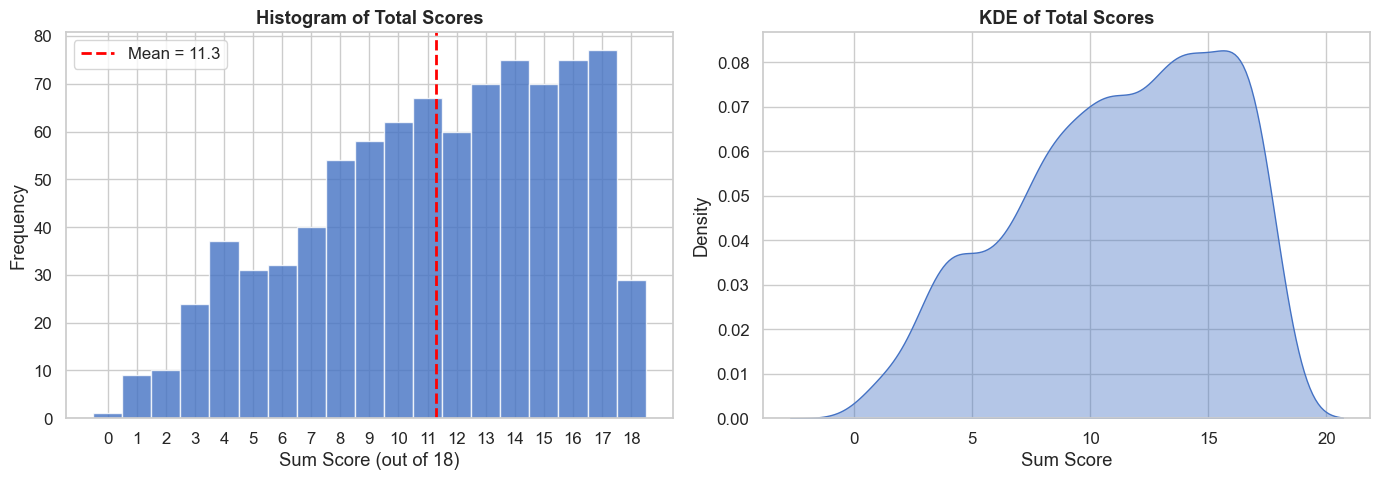

In [12]:
# ── Histogram and KDE of sum scores ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.arange(-0.5, I + 1, 1)  # bins centered on integers
ax.hist(persons['sum_score'], bins=bins, color='#4472C4', edgecolor='white', alpha=0.8)
ax.axvline(persons['sum_score'].mean(), color='red', linestyle='--', lw=2,
           label=f"Mean = {persons['sum_score'].mean():.1f}")
ax.set_xticks(np.arange(-0, I + 1, 1))
ax.set_xlabel('Sum Score (out of 18)'); ax.set_ylabel('Frequency')
ax.set_title('Histogram of Total Scores', fontweight='bold')
ax.legend()

ax = axes[1]
sns.kdeplot(data=persons, x='sum_score', fill=True, color='#4472C4', alpha=0.4, ax=ax, bw_adjust=0.8)
ax.set_xlabel('Sum Score'); ax.set_title('KDE of Total Scores', fontweight='bold')

plt.tight_layout()
plt.show()

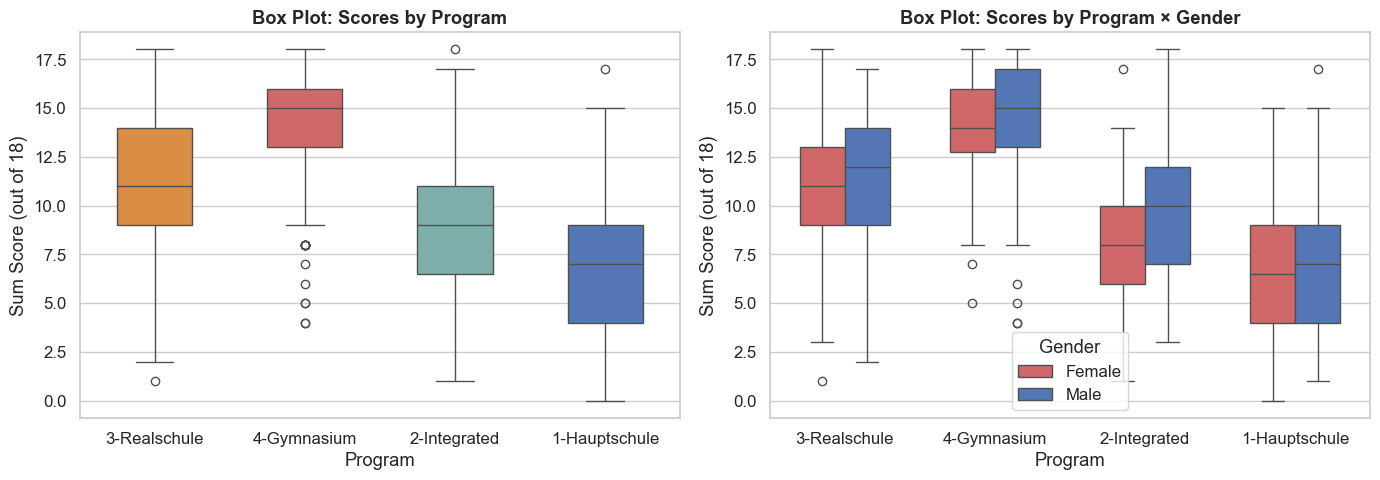

In [13]:
# ── Box plots: sum score by program ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_p = ['#F28E2B', '#E15759', '#76B7B2', '#4472C4']

ax = axes[0]
sns.boxplot(data=persons, x='Program', y='sum_score', hue='Program', palette=colors_p, width=0.5, legend=False, ax=ax)
ax.set_ylabel('Sum Score (out of 18)')
ax.set_title('Box Plot: Scores by Program', fontweight='bold')

ax = axes[1]
sns.boxplot(data=persons, x='Program', y='sum_score', hue='Gender',
            palette={'Female':'#E15759','Male':'#4472C4'}, width=0.6, ax=ax)
ax.set_ylabel('Sum Score (out of 18)')
ax.set_title('Box Plot: Scores by Program × Gender', fontweight='bold')
ax.legend(title='Gender')

plt.tight_layout()
plt.show()

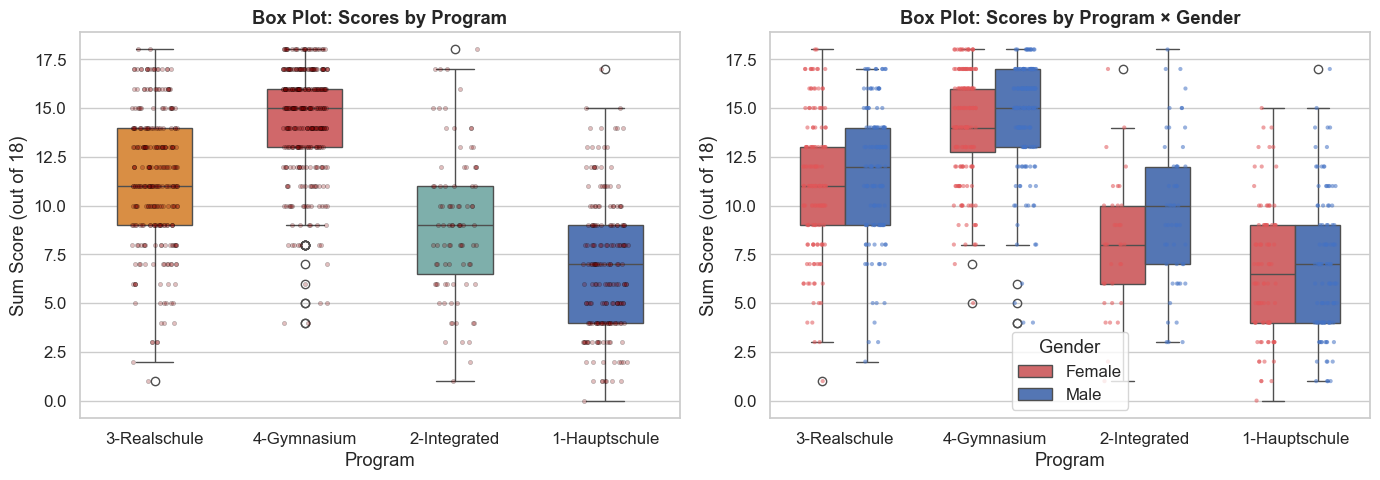

In [14]:
# ── Box plots: sum score by program with dots ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_p = ['#F28E2B', '#E15759', '#76B7B2', '#4472C4']

ax = axes[0]
sns.boxplot(data=persons, x='Program', y='sum_score', hue='Program',
            palette=colors_p, width=0.5, legend=False, ax=ax)
sns.stripplot(data=persons, x='Program', y='sum_score',
              color = 'darkred', edgecolor='black', linewidth=0.5,
            #   hue='Program',
            #   palette=colors_p, 
              dodge=False, jitter=0.15, size=3,
              alpha=0.25, legend=False, ax=ax)
ax.set_ylabel('Sum Score (out of 18)')
ax.set_title('Box Plot: Scores by Program', fontweight='bold')

ax = axes[1]
sns.boxplot(data=persons, x='Program', y='sum_score', hue='Gender',
            palette={'Female':'#E15759','Male':'#4472C4'}, width=0.6, ax=ax)
sns.stripplot(data=persons, x='Program', y='sum_score', hue='Gender',
              palette={'Female':'#E15759','Male':'#4472C4'}, dodge=True,
              jitter=0.15, size=3, alpha=0.55, ax=ax)
ax.set_ylabel('Sum Score (out of 18)')
ax.set_title('Box Plot: Scores by Program × Gender', fontweight='bold')

# Keep one clean gender legend after overlaying box + dots.
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title='Gender')

plt.tight_layout()
plt.show()

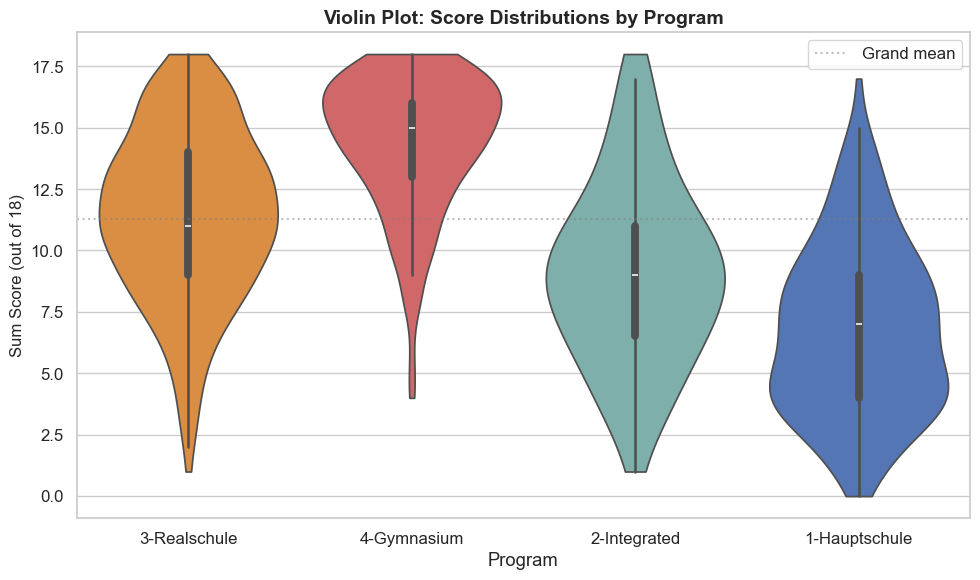

In [15]:
# ── Violin plots: sum score by program ──
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=persons, x='Program', y='sum_score', hue='Program',
               palette=colors_p, inner='box', cut=0, legend=False, ax=ax)
ax.set_ylabel('Sum Score (out of 18)', fontsize=12)
ax.set_title('Violin Plot: Score Distributions by Program', fontweight='bold', fontsize=14)
ax.axhline(persons['sum_score'].mean(), color='gray', linestyle=':', alpha=0.5, label='Grand mean')
ax.legend()

plt.tight_layout()
plt.show()

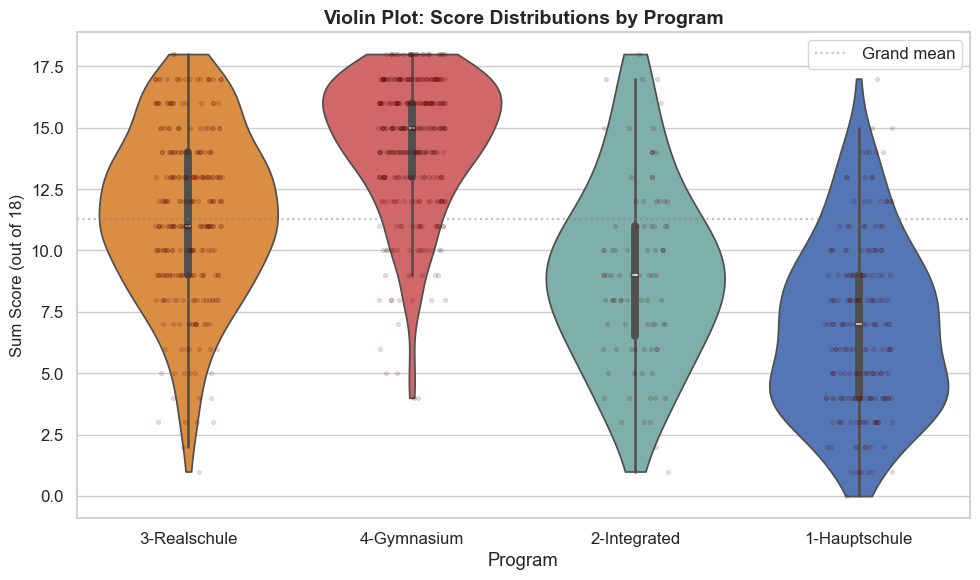

In [16]:
# ── Violin plots: sum score by program ──
fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(data=persons, x='Program', y='sum_score',
              color = 'darkred', edgecolor='black', linewidth=0.5,
              dodge=False, jitter=0.15, size=3, alpha=0.15, ax=ax)
sns.violinplot(data=persons, x='Program', y='sum_score', hue='Program',
               palette=colors_p, inner='box', cut=0, legend=False, ax=ax)
ax.set_ylabel('Sum Score (out of 18)', fontsize=12)
ax.set_title('Violin Plot: Score Distributions by Program', fontweight='bold', fontsize=14)
ax.axhline(persons['sum_score'].mean(), color='gray', linestyle=':', alpha=0.5, label='Grand mean')
ax.legend()

plt.tight_layout()
plt.show()

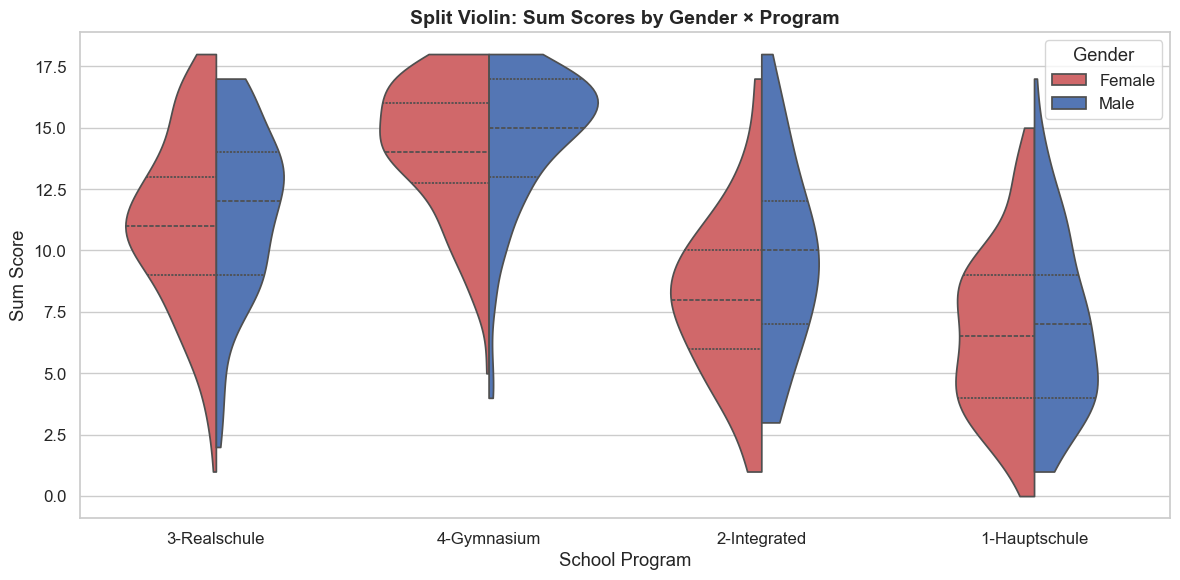

In [17]:
# ── Violin: Gender × Program (split) ──
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=persons, x='Program', y='sum_score', hue='Gender',
               split=True, inner='quart', palette={'Female':'#E15759','Male':'#4472C4'},
               cut=0, ax=ax)
ax.set_ylabel('Sum Score'); ax.set_xlabel('School Program')
ax.set_title('Split Violin: Sum Scores by Gender × Program', fontweight='bold', fontsize=14)
ax.legend(title='Gender')

plt.tight_layout()
plt.show()

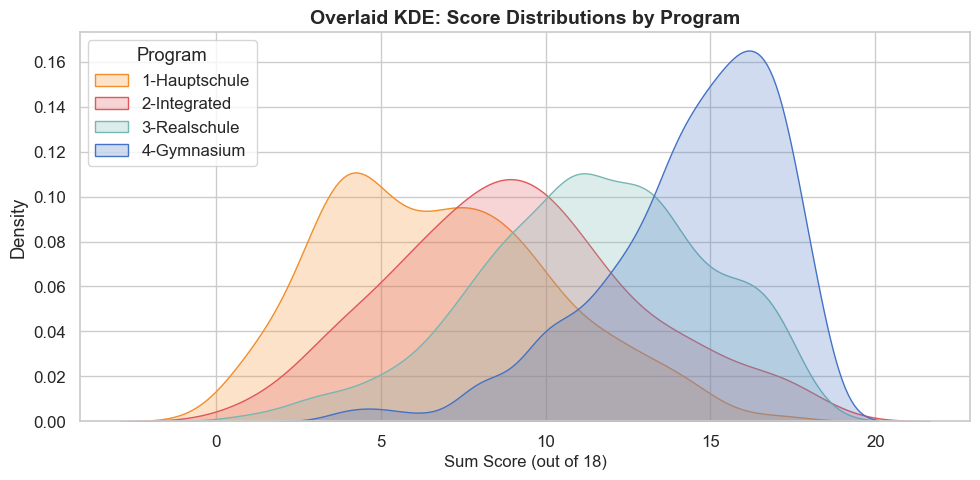

In [18]:
# ── KDE by program ──
fig, ax = plt.subplots(figsize=(10, 5))

for prog, color in zip(['1-Hauptschule','2-Integrated','3-Realschule','4-Gymnasium'], colors_p):
    subset = persons[persons['Program'] == prog]
    sns.kdeplot(data=subset, x='sum_score', fill=True, alpha=0.25, color=color, label=prog, ax=ax, bw_adjust=0.8)

ax.set_xlabel('Sum Score (out of 18)', fontsize=12)
ax.set_title('Overlaid KDE: Score Distributions by Program', fontweight='bold', fontsize=14)
ax.legend(title='Program')

plt.tight_layout()
plt.show()

## 5. Long-Format Data: `data_long.csv`

The same data in long format — one row per person × item combination.

In [19]:
long = pd.read_csv('data_long.csv')
print(f'Shape: {long.shape[0]} rows × {long.shape[1]} columns')
print(f'This is {N} persons × {I} items = {N*I} rows')
print()
long.head(25)

Shape: 15858 rows × 3 columns
This is 881 persons × 18 items = 15858 rows



,person_id,item_id,response
0,0,0,1
1,0,1,1
2,0,2,0
3,0,3,0
4,0,4,1
5,0,5,1
6,0,6,1
7,0,7,0
8,0,8,1
9,0,9,1


In [20]:
long.tail(10)

,person_id,item_id,response
15848,880,8,0
15849,880,9,1
15850,880,10,1
15851,880,11,0
15852,880,12,1
15853,880,13,1
15854,880,14,1
15855,880,15,1
15856,880,16,1
15857,880,17,0


In [21]:
long.describe()

,person_id,item_id,response
count,15858.000000,15858.000000,15858.000000
mean,440.000000,8.500000,0.627317
std,254.330649,5.188291,0.483534
min,0.000000,0.000000,0.000000
25%,220.000000,4.000000,0.000000
50%,440.000000,8.500000,1.000000
75%,660.000000,13.000000,1.000000
max,880.000000,17.000000,1.000000


## 6. Item-Total Correlation & Discrimination

Classical test theory (CTT) metric: how well does each item discriminate between high and low ability?

- **Point-biserial correlation** (점-이분 상관)은  
    이분형 문항 점수 $X_i \in \{0,1\}$와 총점 $T$ 사이의 상관계수입니다.  
    문항을 맞은 집단(1)과 틀린 집단(0)의 **총점 평균 차이**가 클수록 값이 커집니다.

- 이 노트북에서는 **보정된 item-total 상관**을 사용했습니다:  
    $$
    r_{i,(T-i)}=\mathrm{corr}(X_i,\;T-X_i)
    $$
    즉, 문항 $i$를 총점에서 제외한 점수와 상관을 계산해 **part-whole inflation**(자기상관에 의한 과대추정)을 줄입니다.

- 해석(경험적 기준):
    - 이 값이 높을수록(보통 0.3 이상) 해당 문항은 전체 검사가 측정하고자 하는 구인(Construct)과 잘 일치하며, 상위 피험자와 하위 피험자를 잘 구분해준다고 해석합니다.
    - $r < 0.20$: 변별도 낮음 (검토 필요)  
    - $0.20 \sim 0.30$: 경계  
    - $0.30 \sim 0.50$: 양호  
    - $> 0.50$: 매우 양호

- **양(+)의 상관**은 고능력 집단이 해당 문항을 더 자주 맞힌다는 뜻이며,  
    **음(-)의 상관**은 역키 처리 오류, 오답키, 다차원성 가능성을 시사합니다.

- 따라서 point-biserial은 고전검사이론에서 문항 **변별도(discrimination)**를 빠르게 진단하는 핵심 지표입니다.

### Point-Biserial

**점 이연 상관계수(Point-biserial correlation)**라는 명칭의 유래는 이분 변수(Binary variable)를 어떻게 취급하느냐에 대한 통계적 가정에서 시작되었습니다.


1. 명칭의 핵심 의미: 점(Point) + 이연(Biserial)
이 용어는 크게 두 부분으로 나뉩니다.
- Point (점/點): 이분 변수의 두 범주(예: 0과 1)가 **불연속적인 개별적인 '점'**에 불과하다는 가정입니다.
- Biserial (이연/二連): '두 개(Bi)가 연결(Serial)되었다'는 뜻으로, 데이터가 **두 개의 계열(Series)**로 나누어져 있음을 의미합니다.
2. 왜 'Point'가 붙었는가?
- 이것이 일반적인 **이연 상관계수(Biserial correlation)**와 구분되는 결정적인 차이점입니다.
- Biserial (이연/二連): 원래는 연속적인 정규분포를 가진 변수인데, 연구자가 인위적으로 '합격/불합격'처럼 두 그룹으로 나눴다고 가정합니다. (잠재적 연속성 가정)
- Point-Biserial (점 이연/點二連): 이분 변수가 원래부터 딱 끊어진 **명목 척도(Nominal scale)**라고 가정합니다. 즉, 0과  1 사이에는 아무런 연속적인 수치가 존재하지 않고, 데이터가 오직 두 개의 **지점(Point)**에만 존재한다는 뜻입니다.
3. 주요 키워드 정리

    |구분|	영어 (English)	| 한자 (Hanja)	| 의미 설명 |
    | :--- | :--- | :--- | :--- |
    |Point	|Point	|點 (점 점)	|데이터가 연속적이지 않고 특정 지점에 고정됨|
    |Biserial	|Biserial	|二連 (두 이, 이을 연)	|두 개의 계열(집단)로 연결되어 있음|
    |Dichotomous	|Dichotomous	|二分 (두 이, 나눌 분)	|변수의 값이 오직 두 개(0, 1)뿐임|
    |Discrete	|Discrete	|離散 (떠날 이, 흩어질 산)	|수치가 서로 떨어져 있는 이산적인 상태|
    |Correlation|	Correlation	|相關 (서로 상, 관계할 관)	|두 변수 간의 상호 의존 관계|

4. 결론
결국 Point-biserial이라고 부르는 이유는 **"한 변수가 잠재적으로 연속적인 것이 아니라, 실제로 딱딱 끊어진 두 개의 '점(Point)'으로 이루어진 이분 변수"**이기 때문입니다.


In [22]:
# Point-biserial correlation of each item with total score
item_total_r = np.zeros(I)
for i in range(I):
    # Corrected item-total: correlate item with sum of OTHER items
    other_sum = R.sum(axis=1) - R[:, i]
    item_total_r[i] = np.corrcoef(R[:, i], other_sum)[0, 1]

disc_df = pd.DataFrame({
    'item_name': item_names,
    'p_value': item_pvals.round(3),
    'item_total_r': item_total_r.round(3),
    'topic_area': items['topic_area'].values,
})
disc_df.sort_values('item_total_r', ascending=False)

,item_name,p_value,item_total_r,topic_area
8,Geo_Nume_1,0.633,0.473,Geometry
12,Alg_Tech_1,0.666,0.464,Algebra
10,Geo_Abst_1,0.553,0.461,Geometry
16,Alg_Abst_1,0.480,0.458,Algebra
14,Alg_Nume_1,0.560,0.451,Algebra
15,Alg_Nume_2,0.518,0.448,Algebra
11,Geo_Abst_2,0.549,0.444,Geometry
3,Ari_Nume_2,0.586,0.426,Arithmetic
7,Geo_Tech_2,0.664,0.420,Geometry
2,Ari_Nume_1,0.594,0.417,Arithmetic


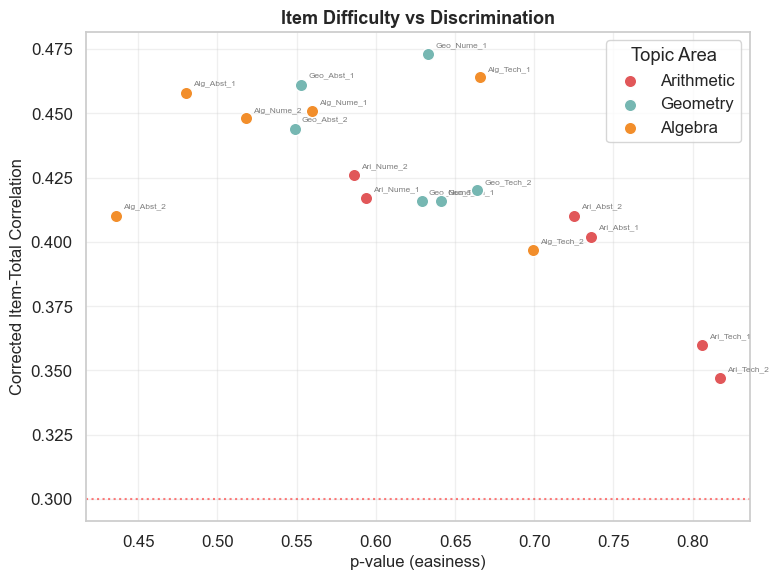

In [23]:
# ── Scatter: p-value vs item-total correlation ──
fig, ax = plt.subplots(figsize=(8, 6))

for ta, color in palette_ta.items():
    mask = disc_df['topic_area'] == ta
    ax.scatter(disc_df.loc[mask, 'p_value'], disc_df.loc[mask, 'item_total_r'],
               c=color, s=80, label=ta, edgecolors='white', zorder=5)

for _, row in disc_df.iterrows():
    ax.annotate(row['item_name'], (row['p_value'], row['item_total_r']),
                xytext=(5, 5), textcoords='offset points', fontsize=6, color='gray')

ax.set_xlabel('p-value (easiness)', fontsize=12)
ax.set_ylabel('Corrected Item-Total Correlation', fontsize=12)
ax.set_title('Item Difficulty vs Discrimination', fontweight='bold', fontsize=13)
ax.legend(title='Topic Area')
ax.axhline(0.3, color='red', linestyle=':', alpha=0.5, label='r = 0.3 threshold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Inter-Item Correlation Matrix

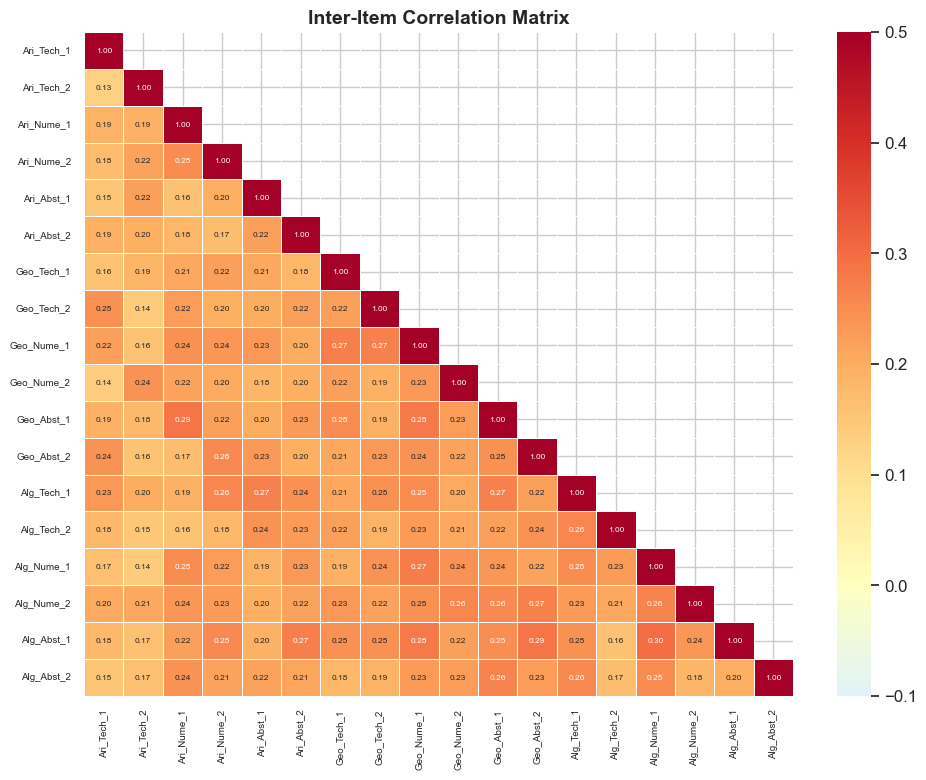

Mean inter-item correlation: 0.217


In [24]:
# Tetrachoric approximation: use Pearson for simplicity with binary data
corr_matrix = np.corrcoef(R.T)  # 18 × 18

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-0.1, vmax=0.5,
            xticklabels=item_names, yticklabels=item_names,
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'fontsize': 6})
ax.set_title('Inter-Item Correlation Matrix', fontweight='bold', fontsize=14)
ax.tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.show()

print(f'Mean inter-item correlation: {corr_matrix[np.tril_indices(I, -1)].mean():.3f}')

## 8. Sum Score vs True Ability

How well does the simple sum score (a classical measure) track the true latent ability?

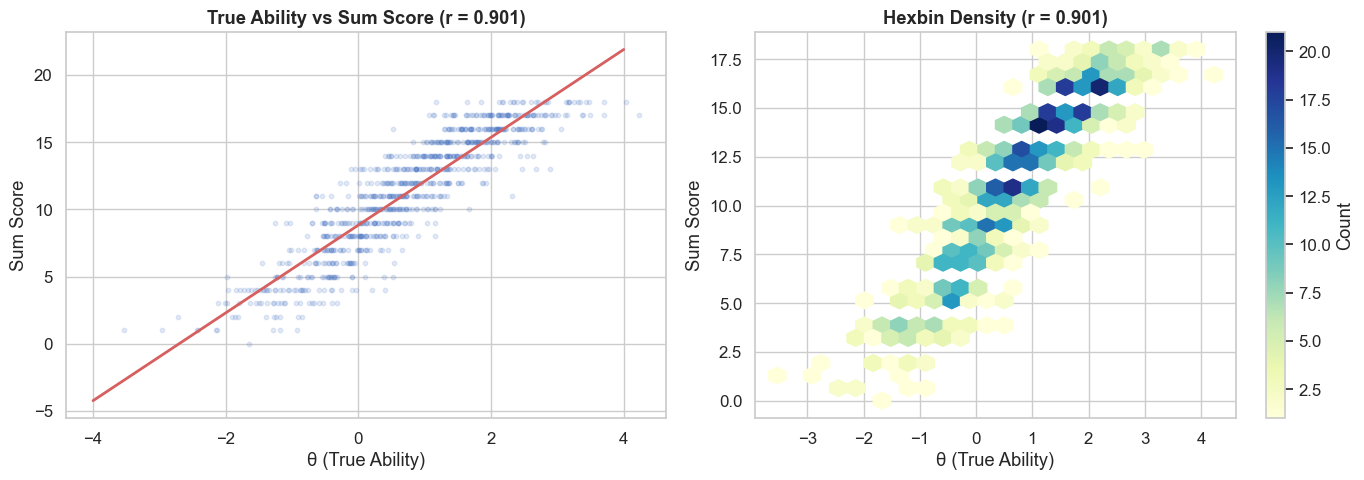

The sum score is a reasonable proxy for ability (r = 0.901),
but IRT models provide more precise, scale-free estimates.


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r_st = np.corrcoef(persons['sum_score'], persons['theta_true'])[0, 1]

ax = axes[0]
ax.scatter(persons['theta_true'], persons['sum_score'], alpha=0.15, s=10, c='#4472C4')
z = np.polyfit(persons['theta_true'], persons['sum_score'], 1)
x_line = np.linspace(-4, 4, 100)
ax.plot(x_line, np.polyval(z, x_line), 'r-', lw=2)
ax.set_xlabel('θ (True Ability)'); ax.set_ylabel('Sum Score')
ax.set_title(f'True Ability vs Sum Score (r = {r_st:.3f})', fontweight='bold')

ax = axes[1]
hb = ax.hexbin(persons['theta_true'], persons['sum_score'], gridsize=25, cmap='YlGnBu', mincnt=1)
ax.set_xlabel('θ (True Ability)'); ax.set_ylabel('Sum Score')
ax.set_title(f'Hexbin Density (r = {r_st:.3f})', fontweight='bold')
plt.colorbar(hb, ax=ax, label='Count')

plt.tight_layout()
plt.show()

print(f'The sum score is a reasonable proxy for ability (r = {r_st:.3f}),')
print(f'but IRT models provide more precise, scale-free estimates.')

## 9. Summary Statistics Table

In [26]:
print('=== Overall ===')
print(f'  Mean score:     {persons["sum_score"].mean():.2f} / {I}')
print(f'  Mean p-value:   {R.mean():.3f}')
print(f'  Cronbach alpha: ', end='')

# Cronbach's alpha
item_vars = R.var(axis=0, ddof=1).sum()
total_var = R.sum(axis=1).var(ddof=1)
alpha = (I / (I - 1)) * (1 - item_vars / total_var)
print(f'{alpha:.3f}')

print()
print('=== By Topic Area ===')
for ta in ['Arithmetic', 'Geometry', 'Algebra']:
    mask = items['topic_area'] == ta
    print(f'  {ta:12s}: mean p = {item_pvals[mask.values].mean():.3f}')

print()
print('=== By Modeling Type ===')
for mt in ['TechnicalProcessing', 'NumericalModeling', 'AbstractModeling']:
    mask = items['modeling_type'] == mt
    print(f'  {mt:22s}: mean p = {item_pvals[mask.values].mean():.3f}')

print()
print('=== By Program ===')
for prog in ['1-Hauptschule','2-Integrated','3-Realschule','4-Gymnasium']:
    mask = persons['Program'] == prog
    print(f'  {prog:16s}: mean score = {persons.loc[mask,"sum_score"].mean():.2f}  (n={mask.sum()})')

=== Overall ===
  Mean score:     11.29 / 18
  Mean p-value:   0.627
  Cronbach alpha: 0.833

=== By Topic Area ===
  Arithmetic  : mean p = 0.711
  Geometry    : mean p = 0.612
  Algebra     : mean p = 0.560

=== By Modeling Type ===
  TechnicalProcessing   : mean p = 0.716
  NumericalModeling     : mean p = 0.586
  AbstractModeling      : mean p = 0.580

=== By Program ===
  1-Hauptschule   : mean score = 6.81  (n=192)
  2-Integrated    : mean score = 9.11  (n=87)
  3-Realschule    : mean score = 11.42  (n=274)
  4-Gymnasium     : mean score = 14.39  (n=328)
